# Evaluación de Resultados
En este notebook se analiza críticamente la calidad de las crónicas generadas,
evaluando coherencia, relevancia, creatividad y fidelidad a los datos del partido.

In [1]:
import pandas as pd
import os
from groq import Groq
from dotenv import load_dotenv

load_dotenv()
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

df_index = pd.read_csv("../reports/indice_cronicas.csv")
print(f"Crónicas generadas: {len(df_index)}")
df_index.head()

Crónicas generadas: 15


,MatchDate,HomeTeam,AwayTeam,FTResult,Upset,archivo
0,2021-03-19,Fulham,Leeds,A,True,../reports/2021-03-19_Fulham_vs_Leeds.txt
1,2018-12-26,Leicester,Man City,H,True,../reports/2018-12-26_Leicester_vs_Man_City.txt
2,2013-04-20,QPR,Stoke,A,True,../reports/2013-04-20_QPR_vs_Stoke.txt
3,2014-05-03,Swansea,Southampton,A,True,../reports/2014-05-03_Swansea_vs_Southampton.txt
4,2004-05-01,Blackburn,Man United,H,True,../reports/2004-05-01_Blackburn_vs_Man_United.txt


## Carga de crónicas generadas
Se leen los archivos de texto generados en el batch anterior.

In [2]:
cronicas = []
for _, row in df_index.iterrows():
    with open(row['archivo'], "r", encoding="utf-8") as f:
        texto = f.read()
    cronicas.append(texto)

df_index['cronica'] = cronicas
df_index['word_count'] = df_index['cronica'].apply(lambda x: len(x.split()))
print(df_index[['HomeTeam', 'AwayTeam', 'MatchDate', 'word_count']])

     HomeTeam     AwayTeam   MatchDate  word_count
0      Fulham        Leeds  2021-03-19         184
1   Leicester     Man City  2018-12-26         195
2         QPR        Stoke  2013-04-20         253
3     Swansea  Southampton  2014-05-03         179
4   Blackburn   Man United  2004-05-01         195
5   West Brom   Birmingham  2010-09-18         228
6    West Ham      Arsenal  2019-12-09         201
7      Fulham      Chelsea  2025-04-20         198
8    Charlton  Aston Villa  2006-12-30         176
9    West Ham    Blackburn  2005-08-13         197
10  West Brom     Man City  2010-11-07         255
11    Burnley    West Brom  2021-02-20         237
12     Bolton       Fulham  2005-04-09         218
13     Bolton    Newcastle  2010-11-20         224
14  Liverpool   Man United  2023-12-17         201


## Evaluación automática con LLM
Se utiliza el mismo modelo para evaluar cada crónica según cuatro criterios:
- **Coherencia**: ¿El texto tiene sentido y fluye bien?
- **Relevancia**: ¿Los datos del partido están bien reflejados?
- **Creatividad**: ¿El lenguaje es variado e interesante?
- **Fidelidad**: ¿No inventa información que no estaba en los datos?

Cada criterio se puntúa del 1 al 5.

In [3]:
import time

def evaluar_cronica(cronica, datos_partido):
    prompt = f"""
Eres un evaluador experto en periodismo deportivo.
Evaluá la siguiente crónica de fútbol según estos criterios, puntuando cada uno del 1 al 5:

1. Coherencia: ¿El texto tiene sentido, fluye bien y es fácil de leer?
2. Relevancia: ¿Los datos del partido (resultado, estadísticas) están bien reflejados?
3. Creatividad: ¿El lenguaje es variado, dinámico e interesante?
4. Fidelidad: ¿La crónica se basa solo en los datos proporcionados sin inventar información?

Datos del partido:
{datos_partido}

Crónica a evaluar:
{cronica}

Respondé ÚNICAMENTE en este formato JSON, sin texto adicional:
{{"coherencia": X, "relevancia": X, "creatividad": X, "fidelidad": X, "comentario": "texto breve"}}
"""
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200
    )
    return response.choices[0].message.content

import json

evaluaciones = []
for i, row in df_index.iterrows():
    datos = f"{row['HomeTeam']} vs {row['AwayTeam']} ({row['MatchDate']}) - Resultado: {row['FTResult']}"
    raw = evaluar_cronica(row['cronica'], datos)
    try:
        eval_dict = json.loads(raw)
    except:
        eval_dict = {"coherencia": None, "relevancia": None, "creatividad": None, "fidelidad": None, "comentario": raw}
    evaluaciones.append(eval_dict)
    print(f"[{i+1}/{len(df_index)}] {row['HomeTeam']} vs {row['AwayTeam']} ✓")
    time.sleep(3)

df_eval = pd.DataFrame(evaluaciones)
df_index = pd.concat([df_index.reset_index(drop=True), df_eval], axis=1)
print("\nEvaluación completada")
df_index[['HomeTeam','AwayTeam','coherencia','relevancia','creatividad','fidelidad']].head(15)

[1/15] Fulham vs Leeds ✓
[2/15] Leicester vs Man City ✓
[3/15] QPR vs Stoke ✓
[4/15] Swansea vs Southampton ✓
[5/15] Blackburn vs Man United ✓
[6/15] West Brom vs Birmingham ✓
[7/15] West Ham vs Arsenal ✓
[8/15] Fulham vs Chelsea ✓
[9/15] Charlton vs Aston Villa ✓
[10/15] West Ham vs Blackburn ✓
[11/15] West Brom vs Man City ✓
[12/15] Burnley vs West Brom ✓
[13/15] Bolton vs Fulham ✓
[14/15] Bolton vs Newcastle ✓
[15/15] Liverpool vs Man United ✓

Evaluación completada


,HomeTeam,AwayTeam,coherencia,relevancia,creatividad,fidelidad
0,Fulham,Leeds,5,4,4,2
1,Leicester,Man City,5,5,4,5
2,QPR,Stoke,5,4,4,2
3,Swansea,Southampton,5,2,4,2
4,Blackburn,Man United,5,4,4,5
5,West Brom,Birmingham,5,5,4,5
6,West Ham,Arsenal,5,3,4,2
7,Fulham,Chelsea,5,2,4,2
8,Charlton,Aston Villa,5,5,4,5
9,West Ham,Blackburn,5,4,4,2


## Análisis de resultados

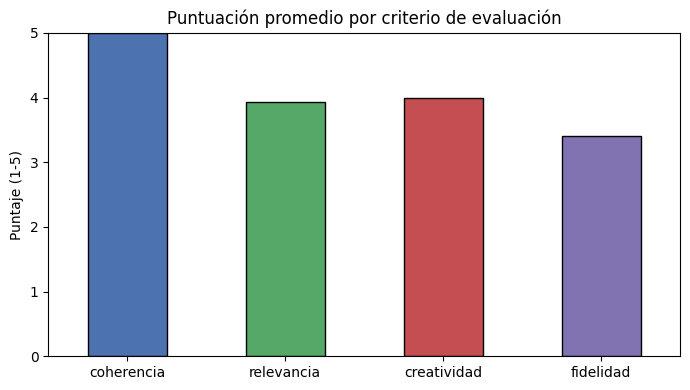


Promedios:
coherencia     5.00
relevancia     3.93
creatividad    4.00
fidelidad      3.40
dtype: float64


In [4]:
import matplotlib.pyplot as plt

criterios = ['coherencia', 'relevancia', 'creatividad', 'fidelidad']
promedios = df_index[criterios].mean()

plt.figure(figsize=(7, 4))
promedios.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2'], edgecolor='black')
plt.title('Puntuación promedio por criterio de evaluación')
plt.ylabel('Puntaje (1-5)')
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nPromedios:")
print(promedios.round(2))

## Conclusiones del equipo
A partir del análisis automático de las 15 crónicas generadas, se identifican los siguientes puntos:

- **Fortalezas**: El modelo alcanzó coherencia perfecta (5.0/5), demostrando que LLaMA 3.3 70B 
  genera texto fluido y bien estructurado de forma consistente. La creatividad (4.0/5) también 
  fue destacada, con lenguaje variado y dinámico en la mayoría de las crónicas.

- **Limitaciones**: La relevancia (3.93/5) y la fidelidad (3.40/5) fueron los criterios más bajos. 
  Al no contar con datos de goleadores, minutos de gol ni eventos puntuales del partido, 
  el modelo tiende a generalizar la narrativa. Además, se detectó que el modelo incorpora 
  detalles inventados pero plausibles (como "en los últimos minutos" o "el arquero fue figura") 
  que no pueden verificarse con los datos disponibles.

- **Mejoras posibles**: Enriquecer el dataset con datos de eventos por partido (disponibles en 
  StatsBomb Open Data) para aumentar la fidelidad. Incorporar embeddings y una base vectorial 
  para recuperar contexto histórico entre equipos (historial de enfrentamientos, rachas) 
  y alimentar el prompt con información más específica.

In [5]:
df_index.to_csv("../reports/evaluacion_cronicas.csv", index=False)
print("Evaluación guardada en reports/evaluacion_cronicas.csv")

Evaluación guardada en reports/evaluacion_cronicas.csv
